In [ ]:
%pip install drama

In [ ]:
import numpy as np  # This is the common way to import numpy and give it a shorter namespace
from matplotlib import pyplot as plt  # Also pretty standard
from drama import utils
import os  # to operate with paths, etc.
%matplotlib widget

# Geometry
## SAR Image
Single image is 2D 
- Azimuth coordinate (from absolute time)  corresponds to a horizontal coordinate on Earth
- Range coordinate (from return time) corresponds to a mixed horizontal/vertical coordinate

## SAR SLC observations

SLC: Single-Look Complex data
- Single-look: no averageing, finest spatial resolution
- Complex: both real and imaginary (In-Phase and quadrature phase)

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlretrieve

data_url = "https://zenodo.org/records/19887026/files/module_1_data_b.npz?download=1"
data_path = "data/module_1_data_b.npz"

os.makedirs("data", exist_ok=True)

if not os.path.isfile(data_path):
    print("Downloading data, this may take a moment (561 MB)...")
    urlretrieve(data_url, data_path)
    print("Done!")

['slc_1', 'dem', 'd_azimuth', 'd_slantrange', 'flatearth_phase', 'slc_2', 'h_amb']


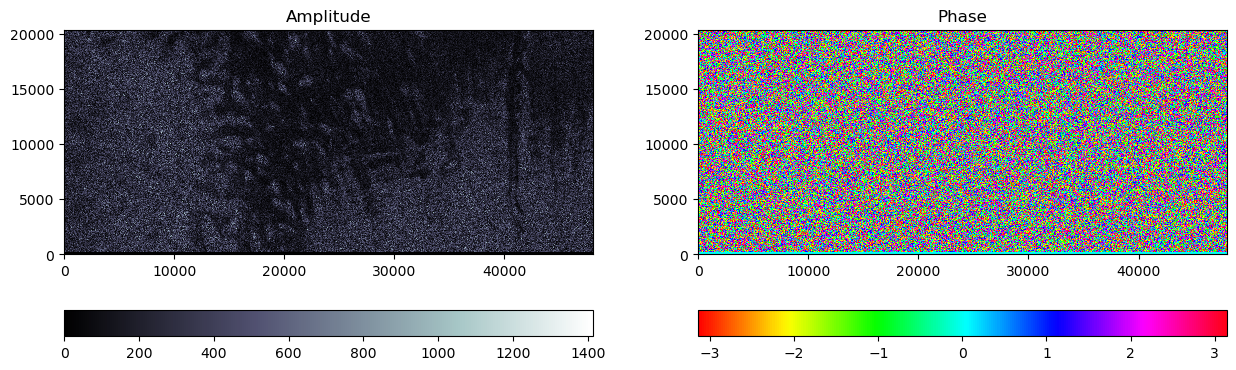

In [ ]:
# I usually set a path to my working directory
path = 'data/'
# And then combine it with the files
data_filename = os.path.join(path, 'module_1_data_b.npz')
npzfile = np.load(data_filename)
# Check what is inside npzfile
slc_1 = npzfile['slc_1']

#visualise amplitude and phase
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
corners = [0, 12000 * 4, 0, 1458*14]

amplitude = ax[0].imshow(np.abs(slc_1[:,0:12000]), cmap='bone', extent=corners, interpolation='None')
ax[0].set_title('Amplitude')
#add colorbar below amplitude plot
fig.colorbar(amplitude, ax=ax[0], orientation='horizontal', pad=0.12)

phase = ax[1].imshow(np.angle(slc_1[:,0:12000]), cmap='hsv', extent=corners, interpolation='None')
ax[1].set_title('Phase')
#add colorbar below phase plot
fig.colorbar(phase, ax=ax[1], orientation='horizontal', pad=0.12)

plt.show()



Using the interferometric configuration sketched in fig we derive the physical and the geometrical relationships between the two phase observations to obtain topographic height and surface deformation estimates.


$$
y_1 = |y_1|exp(j\psi_1)
$$
$$
y_2 = |y_2|exp(j\psi_2)
$$
$$
\mu=y_1y_2^*= |y_1||y_2|\exp{(j \psi_1-\psi_2)}
$$

$$
\frac{2R_1}{\lambda}= \frac{\psi_1}{2\pi}
$$

$$
\psi_1 = -\frac{4\pi}{\lambda}R_1
$$
$$
\psi_2 = -\frac{4\pi}{\lambda}R_2
$$

Interferometric phase:
$$
\phi_p = \psi_{1p}-\psi_{2p}= - \frac{4\pi(R_1-R_2)}{\lambda}= - \frac{4\pi\Delta R}{\lambda}
$$




```{figure} figures/interferometric_configuration.png
---
height: 300px
name: interf_config

---

```

$$
\phi_p =  - \frac{4\pi\Delta R}{\lambda}
$$

$$
\partial \phi_p= -\frac{4 \pi}{\lambda}\partial \Delta R
$$

$$
\Delta R = B\sin(\theta-\alpha)
$$
$$
\partial \Delta R = B\cos(\theta^{\circ}-\alpha)\partial \theta
$$
initial value of $\theta^{\circ}$ is obtained for the reference surface
$$
\partial \phi_p = -\frac{4 \pi}{\lambda} B\cos(\theta^{\circ}-\alpha)\partial \theta
$$

$$
H_p = R_1 \partial \theta \sin\theta^{\circ}
$$

$$
H_p =  -\frac{\lambda R_1 \sin\theta^{\circ} }{4 \pi} \partial\phi_p
$$

